In [2]:
# All the imports

import numpy as np
np.set_printoptions(legacy='1.25')
import math
from skfem import MeshQuad, MeshTri, Basis, asm, condense
from skfem.element import ElementQuad1, ElementTriP1
from skfem.models.poisson import laplace
from skfem.helpers import dot, grad
from skfem import BilinearForm, LinearForm
from skfem.utils import solve
import matplotlib.pyplot as plt
from skfem.visuals.matplotlib import plot
from scipy.sparse.linalg import eigsh, ArpackNoConvergence
import pickle
from scipy.sparse.linalg import splu, LinearOperator, eigsh
from skfem.helpers import dot, grad
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import curve_fit
from mpl_toolkits.mplot3d import Axes3D
import itertools
import os

from eigenvector_convergence.eigenvector_helpers import (
    Absorption_checkerboard, D_checkerboard, D_random, Fission_checkerboard,
    _tensor_product_basis, a_checkerboard, a_random, b_checkerboard,
    eigvecs_at_level, fix_sign,
    plot_bilinear_hat_solution, _validate_analysis_dimension, _solution_tensor, _grid_points_and_interior_mask,
    get_uniform_superposition_overlaps,
)

Function for running simulations given lists of desired diffusion coefficients, absorption cross sections, and fission production cross sections and returning the eigenvector_l2_error_list and coarse_sol_overlap_list


In [2]:
def get_coarse_overlaps(material_coefficients, min_r, max_refinement, ref_refinement, mat_r, geometry="checkerboard", dim=2):
    dim = _validate_analysis_dimension(dim)
    coarse_sol_overlap_list = [] # list of coarse solution overlaps for each D_max
    eigenvector_l2_error_list = [] # list of L2 errors between coarse and reference solutions for each D_max
    for D_max, sigma_a_max, sigma_f_max in material_coefficients:
        Data_dict_dmax_1 = {"levels": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

        # loop through the coarse refinement levels and compute the corresponding eigenvectors
        for r in range(min_r, max_refinement+1): 
            lambda1, u_full = eigvecs_at_level(mat_r=mat_r, r=r, D_max=D_max, D_min=1.0, sigma_a_max=sigma_a_max, sigma_a_min=1.0, sigma_f_max=sigma_f_max, sigma_f_min=1.0, do_plot=False, geometry=geometry, dim=dim)
            Data_dict_dmax_1["levels"].append(r)
            Data_dict_dmax_1["lambda1"].append(float(lambda1))
            Data_dict_dmax_1["full_size"].append(len(u_full)) 
            points_per_axis = 2**r + 1
            Data_dict_dmax_1["free_size"].append((points_per_axis - 2) ** dim)
            Data_dict_dmax_1["u_full"].append(fix_sign(u_full))
            print(f"D_max: {D_max}, sigma_a_max: {sigma_a_max}, sigma_f_max: {sigma_f_max}, level: {r}, lambda1: {lambda1}, full_size: {len(u_full)}")

        # Use the finest eigenvector as the reference and interpolate every coarse
        # eigenvector onto its grid.  Eigenvectors have an arbitrary sign, so fix
        # that sign before normalizing and comparing their interior DOFs.
        lambda1, reference_solution = eigvecs_at_level(mat_r=mat_r, r=ref_refinement, D_max=D_max, D_min=1.0, sigma_a_max=sigma_a_max, sigma_a_min=1.0, sigma_f_max=sigma_f_max, sigma_f_min=1.0, do_plot=False, geometry=geometry, dim=dim)
        reference_solution = fix_sign(reference_solution)
        reference_grid, reference_points, interior_mask = (
            _grid_points_and_interior_mask(ref_refinement, dim)
        )
        reference_values = _solution_tensor(
            reference_solution, ref_refinement, dim
        )
        reference_interior = reference_values.ravel()[interior_mask]
        reference_interior_normalized = reference_interior / np.linalg.norm(reference_interior)

        # store interpolated, normalized coarse solutions 
        interpolated_coarse_solutions = []
        interpolated_interior_coarse_normalized_solutions = []
        eigenvector_l2_errors = []
        for coarse_r, coarse_solution in zip(
            Data_dict_dmax_1["levels"], Data_dict_dmax_1["u_full"]
        ):
            coarse_solution = fix_sign(coarse_solution.copy())
            coarse_grid, _, _ = _grid_points_and_interior_mask(
                coarse_r, dim
            )
            coarse_values = _solution_tensor(
                coarse_solution, coarse_r, dim
            )
            coarse_interpolator = RegularGridInterpolator(
                (coarse_grid,) * dim, coarse_values, method="linear"
            )
            interpolated_solution = coarse_interpolator(reference_points)
            interpolated_coarse_solutions.append(interpolated_solution)

            interpolated_interior = interpolated_solution[interior_mask]
            interpolated_interior_normalized = (
                interpolated_interior / np.linalg.norm(interpolated_interior)
            )
            interpolated_interior_coarse_normalized_solutions.append(interpolated_interior_normalized)

            eigenvector_l2_errors.append(
                np.linalg.norm(interpolated_interior_normalized - reference_interior_normalized)
            )

        # write the relevant data to the dictionary for the current D_max
        Data_dict_dmax_1["reference_solution"] = reference_solution
        Data_dict_dmax_1["reference_interior_normalized"] = reference_interior_normalized
        Data_dict_dmax_1["interpolated_coarse_solutions"] = interpolated_coarse_solutions
        Data_dict_dmax_1["interpolated_interior_coarse_normalized_solutions"] = interpolated_interior_coarse_normalized_solutions
        Data_dict_dmax_1["chi"] = eigenvector_l2_errors

        # print and plot eigenvector results
        for r in range(min_r, max_refinement+1):
            flux_solution = _solution_tensor(
                Data_dict_dmax_1["u_full"][r-min_r], r, dim
            )
            grid_1D = np.linspace(0,1,int(2**r+1))

            flux_solution_interpolated = Data_dict_dmax_1["interpolated_coarse_solutions"][r-min_r].reshape((int(2**ref_refinement+1),) * dim)
            grid_1D_interpolated = np.linspace(0,1,int(2**(ref_refinement)+1))

            # plot the original and interpolated coarse solutions
            #plot_bilinear_hat_solution(flux_solution, *([grid_1D] * dim), plot_type="heatmap")
            #plot_bilinear_hat_solution(flux_solution_interpolated, *([grid_1D_interpolated] * dim), plot_type="heatmap")
            #print(f"Plotted refinement level {r}")

        # compute the overlap of the interpolated coarse solutions with the reference solution
        coarse_sol_overlaps = [np.dot(Data_dict_dmax_1["interpolated_interior_coarse_normalized_solutions"][r], Data_dict_dmax_1["reference_interior_normalized"]) for r in range(0, max_refinement-min_r+1)]
        coarse_sol_overlap_list.append(coarse_sol_overlaps)
        eigenvector_l2_error_list.append(Data_dict_dmax_1["chi"])

        print("Refinement values: ", list(range(min_r, max_refinement+1)))
        #print(r'\hat{u}_c', Data_dict_dmax_1["interpolated_interior_coarse_normalized_solutions"])
        #print(r'\hat{u}_f', Data_dict_dmax_1["reference_interior_normalized"])
        print(r'|| \hat{u}_c - \hat{u}_f || :', Data_dict_dmax_1["chi"])
        print(r'< \hat{u}_c | \hat{u}_f> :', coarse_sol_overlaps)

    return coarse_sol_overlap_list

# 2 Material Checkerboard Simulations

D_max: 1, sigma_a_max: 10, sigma_f_max: 10, level: 1, lambda1: 5.363636363636364, full_size: 9
D_max: 1, sigma_a_max: 10, sigma_f_max: 10, level: 2, lambda1: 4.7754727744189776, full_size: 25
D_max: 1, sigma_a_max: 10, sigma_f_max: 10, level: 3, lambda1: 4.561323949845413, full_size: 81
D_max: 1, sigma_a_max: 10, sigma_f_max: 10, level: 4, lambda1: 4.501704221446694, full_size: 289
D_max: 1, sigma_a_max: 10, sigma_f_max: 10, level: 5, lambda1: 4.486481426310883, full_size: 1089
D_max: 1, sigma_a_max: 10, sigma_f_max: 10, level: 6, lambda1: 4.482650080614295, full_size: 4225
Refinement values:  [1, 2, 3, 4, 5, 6]
|| \hat{u}_c - \hat{u}_f || : [0.17608378204567007, 0.0579621345169027, 0.016758524483873133, 0.004406211196292438, 0.001134078184096027, 0.0002997345369235977]
< \hat{u}_c | \hat{u}_f> : [0.9844972508502465, 0.9983201954811223, 0.9998595759285619, 0.9999902926514469, 0.9999993569333365, 0.9999999550796038]
D_max: 3, sigma_a_max: 10, sigma_f_max: 10, level: 1, lambda1: 9.727272

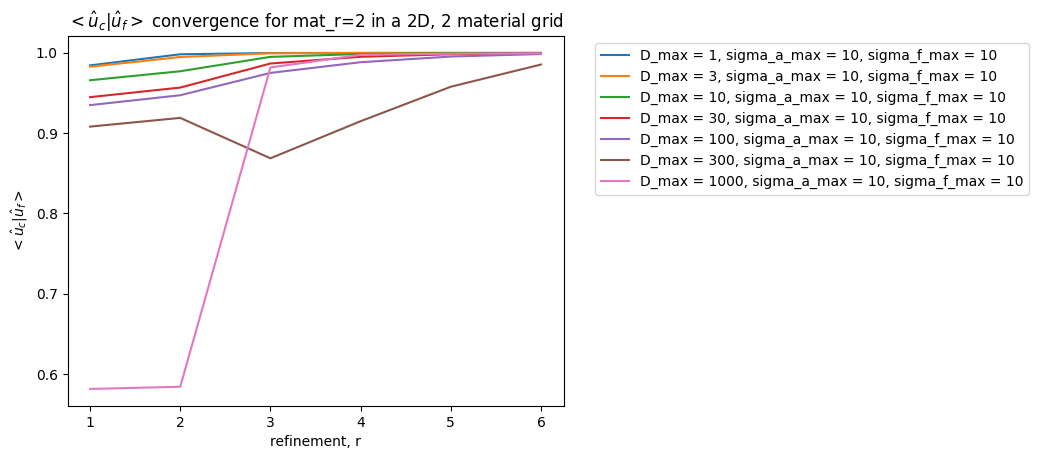

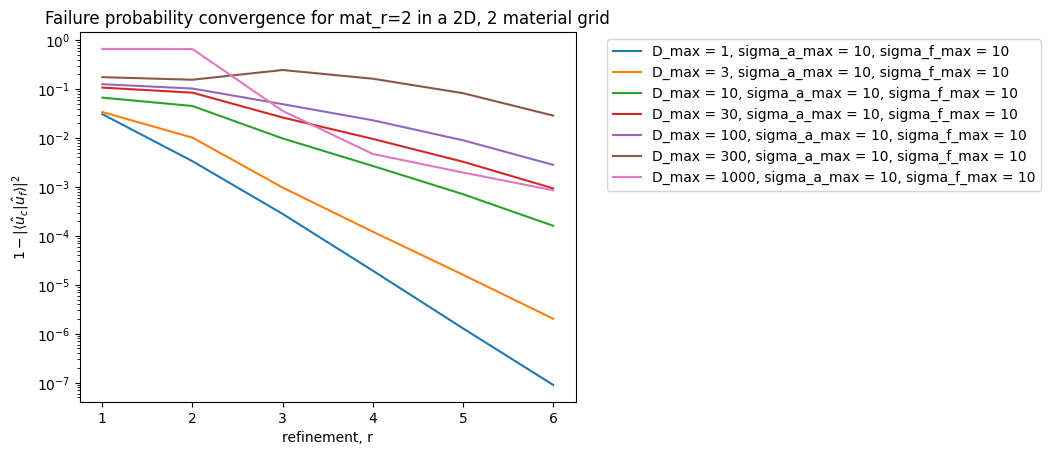

In [5]:
max_refinement = 6 # maximum refinement level for the coarse solutions
ref_refinement = 8 # refinement level for the reference solution
mat_r = 2 # refinement level of the 2-material checkerboard material grid
min_r = 1 # minimum refinement level for the coarse solutions
D_max_list = [1,3, 10, 30, 100, 300, 1000]
sigma_a_max_list = [10]
sigma_f_max_list = [10]

#material_coefficients = [(D_max, sigma_a_max, sigma_f_max) for D_max in D_max_list for sigma_a_max in sigma_a_max_list for sigma_f_max in sigma_f_max_list]
material_coefficients = list(itertools.product(D_max_list, sigma_a_max_list, sigma_f_max_list))
material_labels = [f"D_max = {D_max}, sigma_a_max = {sigma_a_max}, sigma_f_max = {sigma_f_max}" for D_max, sigma_a_max, sigma_f_max in material_coefficients]
coarse_sol_overlap_list = get_coarse_overlaps(material_coefficients, min_r, max_refinement, ref_refinement, mat_r, geometry="checkerboard")

# plot the l2 norm of the error between the fine and coarse states
'''for i in range(len(D_max_list)):
    plt.semilogy(list(range(min_r, max_refinement+1)), eigenvector_l2_error_list[i])
    plt.xlabel("refinement, r")
    plt.ylabel(r'$|| \hat{u}_c - \hat{u}_f ||$')
plt.title(r'$|| \hat{u}_c - \hat{u}_f ||$ convergence for mat_r=' + str(mat_r) + ' in a 2D, 2 material grid')
plt.legend([f"D_max = {D_max}" for D_max in D_max_list])
plt.show()'''

# plot the inner product of the fine and coarse states
for i in range(len(D_max_list)*len(sigma_a_max_list)*len(sigma_f_max_list)):
    plt.plot(list(range(min_r, max_refinement+1)), coarse_sol_overlap_list[i], label=material_labels[i])
    plt.xlabel("refinement, r")
    plt.ylabel(r'$< \hat{u}_c | \hat{u}_f>$')
plt.title(r'$< \hat{u}_c | \hat{u}_f>$ convergence for mat_r=' + str(mat_r) + ' in a 2D, 2 material grid')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.show()

# Plot the failure probability, one minus the squared coarse-to-fine overlap.
for i in range(len(D_max_list)*len(sigma_a_max_list)*len(sigma_f_max_list)):
    plt.semilogy(list(range(min_r, max_refinement+1)), 1 - np.square(coarse_sol_overlap_list[i]), label=material_labels[i])
    plt.xlabel("refinement, r")
    plt.ylabel(r'$1 - |\langle \hat{u}_c | \hat{u}_f \rangle|^2$')
plt.title(r'Failure probability convergence for mat_r=' + str(mat_r) + ' in a 2D, 2 material grid')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.show()




# Random Material Grid
Now every material region has a diffusion coefficient uniformly randomly sampled from the range $[D_{min}, D_{max}]$

D_max: 1, sigma_a_max: 10, sigma_f_max: 10, level: 1, lambda1: 4.545454545454546, full_size: 9
D_max: 1, sigma_a_max: 10, sigma_f_max: 10, level: 2, lambda1: 3.9571442588533188, full_size: 25
D_max: 1, sigma_a_max: 10, sigma_f_max: 10, level: 3, lambda1: 3.73572530730282, full_size: 81
D_max: 1, sigma_a_max: 10, sigma_f_max: 10, level: 4, lambda1: 3.6736006853338554, full_size: 289
D_max: 1, sigma_a_max: 10, sigma_f_max: 10, level: 5, lambda1: 3.657715252756673, full_size: 1089
D_max: 1, sigma_a_max: 10, sigma_f_max: 10, level: 6, lambda1: 3.65371541861323, full_size: 4225
Refinement values:  [1, 2, 3, 4, 5, 6]
|| \hat{u}_c - \hat{u}_f || : [0.1766700930724754, 0.05978136399316294, 0.017380598900765837, 0.0045747645425520045, 0.0011769657266640396, 0.0003103112027916143]
< \hat{u}_c | \hat{u}_f> : [0.9843938391068813, 0.9982130942595585, 0.9998489573909254, 0.99998953576469, 0.9999993073758389, 0.9999999518534787]
D_max: 3, sigma_a_max: 10, sigma_f_max: 10, level: 1, lambda1: 8.9090909

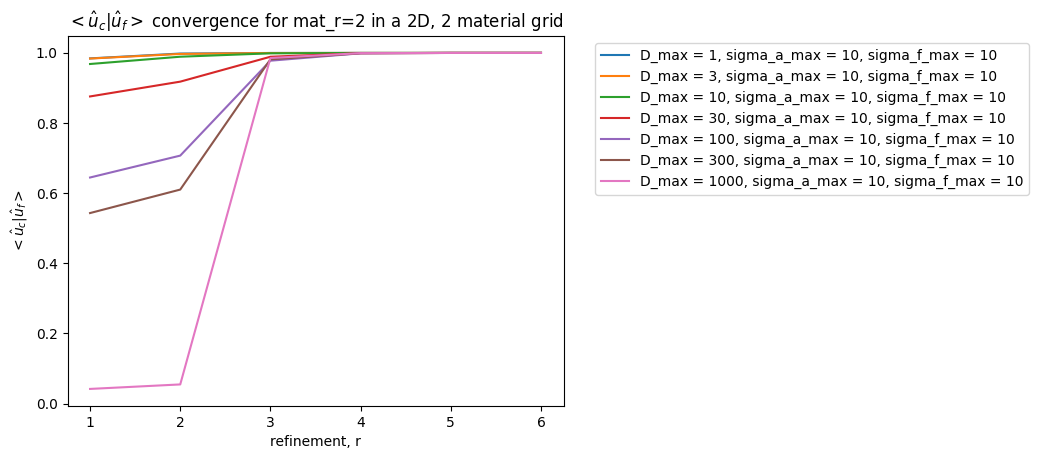

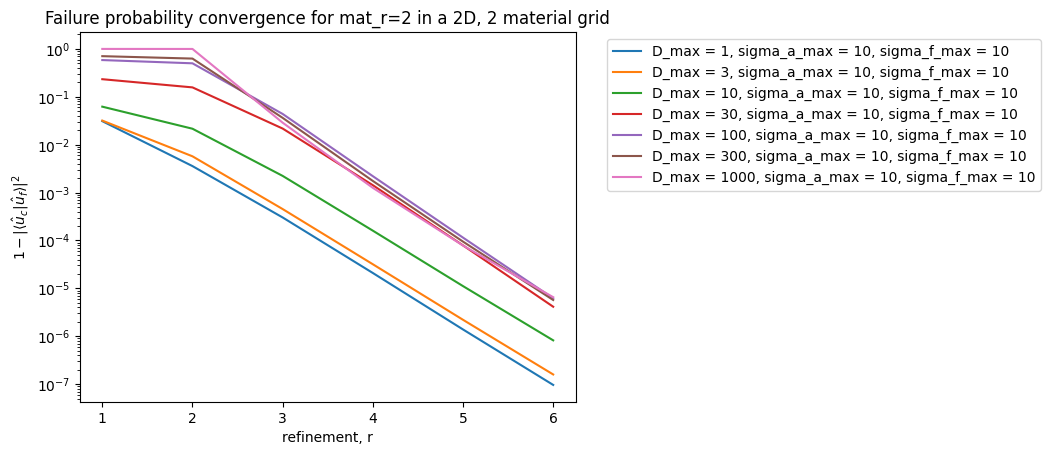

In [6]:
max_refinement = 6 # maximum refinement level for the coarse solutions
ref_refinement = 8 # refinement level for the reference solution
mat_r = 2 # refinement level of the 2-material checkerboard material grid
min_r = 1 # minimum refinement level for the coarse solutions
D_max_list = [1,3, 10, 30, 100, 300, 1000]
sigma_a_max_list = [10]
sigma_f_max_list = [10]

#material_coefficients = [(D_max, sigma_a_max, sigma_f_max) for D_max in D_max_list for sigma_a_max in sigma_a_max_list for sigma_f_max in sigma_f_max_list]
material_coefficients = list(itertools.product(D_max_list, sigma_a_max_list, sigma_f_max_list))
material_labels = [f"D_max = {D_max}, sigma_a_max = {sigma_a_max}, sigma_f_max = {sigma_f_max}" for D_max, sigma_a_max, sigma_f_max in material_coefficients]
coarse_sol_overlap_list = get_coarse_overlaps(material_coefficients, min_r, max_refinement, ref_refinement, mat_r, geometry="random")

# plot the l2 norm of the error between the fine and coarse states
'''for i in range(len(D_max_list)):
    plt.semilogy(list(range(min_r, max_refinement+1)), eigenvector_l2_error_list[i])
    plt.xlabel("refinement, r")
    plt.ylabel(r'$|| \hat{u}_c - \hat{u}_f ||$')
plt.title(r'$|| \hat{u}_c - \hat{u}_f ||$ convergence for mat_r=' + str(mat_r) + ' in a 2D, 2 material grid')
plt.legend([f"D_max = {D_max}" for D_max in D_max_list])
plt.show()'''

# plot the inner product of the fine and coarse states
for i in range(len(D_max_list)*len(sigma_a_max_list)*len(sigma_f_max_list)):
    plt.plot(list(range(min_r, max_refinement+1)), coarse_sol_overlap_list[i], label=material_labels[i])
    plt.xlabel("refinement, r")
    plt.ylabel(r'$< \hat{u}_c | \hat{u}_f>$')
plt.title(r'$< \hat{u}_c | \hat{u}_f>$ convergence for mat_r=' + str(mat_r) + ' in a 2D, 2 material grid')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.show()

# Plot the failure probability, one minus the squared coarse-to-fine overlap.
for i in range(len(D_max_list)*len(sigma_a_max_list)*len(sigma_f_max_list)):
    plt.semilogy(list(range(min_r, max_refinement+1)), 1 - np.square(coarse_sol_overlap_list[i]), label=material_labels[i])
    plt.xlabel("refinement, r")
    plt.ylabel(r'$1 - |\langle \hat{u}_c | \hat{u}_f \rangle|^2$')
plt.title(r'Failure probability convergence for mat_r=' + str(mat_r) + ' in a 2D, 2 material grid')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.show()




# constant coarse discretization, varied fine discretization

In [7]:
# Compute the overlaps and L2 errors of fine grid eigenvectors with respect to a coarse reference solution.
# material coefficients: an iteraterable object containing tuples of the form (D_max, sigma_a_max, sigma_f_max)
# min_r: minimum refinement level for the fine grid
# max_refinement: maximum refinement level for the fine grid
# coarse_refinement: refinement level for the coarse reference solution
# mat_r: material refinement level
def get_fine_overlaps(material_coefficients, min_r, max_refinement, coarse_refinement, mat_r, geometry="checkerboard", dim=2):
    dim = _validate_analysis_dimension(dim)
    fine_sol_overlap_list = [] # coarse-to-fine overlaps for each material-coefficient tuple
    successive_fine_overlap_list = [] # overlaps between fine solutions at levels r and r+1
    eigenvector_l2_error_list = [] # list of L2 errors between coarse and reference solutions for each D_max
    for D_max, sigma_a_max, sigma_f_max in material_coefficients:
        Data_dict_dmax_1 = {"levels": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

        # Find the coarse solution
        lambda1, coarse_solution = eigvecs_at_level(mat_r=mat_r, r=coarse_refinement, D_max=D_max, D_min=1.0, sigma_a_max=sigma_a_max, sigma_a_min=1.0, sigma_f_max=sigma_f_max, sigma_f_min=1.0, do_plot=False, geometry=geometry, dim=dim)
        coarse_solution = fix_sign(coarse_solution)

        # store overlap information for each fine refinement level
        fine_sol_overlaps = []
        successive_fine_overlaps = []
        eigenvector_l2_errors = []
        previous_fine_solution = None

        # loop through the fine refinement levels and compute the corresponding eigenvectors
        for r in range(min_r, max_refinement+1): 
            lambda1, fine_solution = eigvecs_at_level(mat_r=mat_r, r=r, D_max=D_max, D_min=1.0, sigma_a_max=sigma_a_max, sigma_a_min=1.0, sigma_f_max=sigma_f_max, sigma_f_min=1.0, do_plot=False, geometry=geometry, dim=dim)
            fine_solution = fix_sign(fine_solution)
            Data_dict_dmax_1["levels"].append(r)
            Data_dict_dmax_1["lambda1"].append(float(lambda1))
            Data_dict_dmax_1["full_size"].append(len(fine_solution)) 
            points_per_axis = 2**r + 1
            Data_dict_dmax_1["free_size"].append((points_per_axis - 2) ** dim)
            Data_dict_dmax_1["u_full"].append(fix_sign(fine_solution))
            print(f"D_max: {D_max}, sigma_a_max: {sigma_a_max}, sigma_f_max: {sigma_f_max}, level: {r}, lambda1: {lambda1}, full_size: {len(fine_solution)}")

            fine_points_per_axis = 2**r + 1
            fine_grid, fine_points, interior_mask = (
                _grid_points_and_interior_mask(r, dim)
            )
            fine_values = _solution_tensor(fine_solution, r, dim)
            fine_interior = fine_values.ravel()[interior_mask]
            fine_interior_normalized = fine_interior / np.linalg.norm(fine_interior)

            # Compare the previous fine solution (level r-1) with the current
            # fine solution after interpolating it onto the current grid.
            if previous_fine_solution is not None:
                previous_r = r - 1
                previous_grid, _, _ = _grid_points_and_interior_mask(
                    previous_r, dim
                )
                previous_values = _solution_tensor(
                    previous_fine_solution, previous_r, dim
                )
                previous_interpolator = RegularGridInterpolator(
                    (previous_grid,) * dim, previous_values, method="linear"
                )
                previous_interpolated = previous_interpolator(fine_points)
                previous_interpolated_interior = previous_interpolated[interior_mask]
                previous_interpolated_interior /= np.linalg.norm(
                    previous_interpolated_interior
                )
                successive_fine_overlaps.append(
                    abs(np.dot(previous_interpolated_interior, fine_interior_normalized))
                )

            previous_fine_solution = fine_solution.copy()

            # interpolate the coarse solution onto the fine grid and find overlap to fine solution
            coarse_solution = fix_sign(coarse_solution.copy())
            coarse_grid, _, _ = _grid_points_and_interior_mask(
                coarse_refinement, dim
            )
            coarse_values = _solution_tensor(
                coarse_solution, coarse_refinement, dim
            )
            coarse_interpolator = RegularGridInterpolator(
                (coarse_grid,) * dim, coarse_values, method="linear"
            )
            interpolated_solution = coarse_interpolator(fine_points)
            interpolated_interior = interpolated_solution[interior_mask]
            interpolated_interior_normalized = (
                interpolated_interior / np.linalg.norm(interpolated_interior)
            )

            # write results to lists
            eigenvector_l2_errors.append(
                np.linalg.norm(interpolated_interior_normalized - fine_interior_normalized)
            )
            fine_sol_overlaps.append(
                np.dot(interpolated_interior_normalized, fine_interior_normalized)
            )


        # compute the overlap of the interpolated coarse solutions with the reference solution
        #coarse_sol_overlaps = [np.dot(Data_dict_dmax_1["interpolated_interior_coarse_normalized_solutions"][r], Data_dict_dmax_1["fine_interior_normalized"]) for r in range(0, max_refinement-min_r+1)]
        fine_sol_overlap_list.append(fine_sol_overlaps)
        successive_fine_overlap_list.append(successive_fine_overlaps)
        eigenvector_l2_error_list.append(eigenvector_l2_errors)

        print("Refinement values: ", list(range(min_r, max_refinement+1)))
        #print(r'\hat{u}_c', Data_dict_dmax_1["interpolated_interior_coarse_normalized_solutions"])
        #print(r'\hat{u}_f', Data_dict_dmax_1["reference_interior_normalized"])
        print(r'|| \hat{u}_c - \hat{u}_f || :', eigenvector_l2_errors)
        print(r'< \hat{u}_c | \hat{u}_f> :', fine_sol_overlaps)
        print(r'< \hat{u}_r | \hat{u}_{r+1}> :', successive_fine_overlaps)

    return fine_sol_overlap_list, successive_fine_overlap_list

# Checkerboard fine grid test

D_max: 1, sigma_a_max: 1, sigma_f_max: 1, level: 5, lambda1: 20.755068235068755, full_size: 1089
D_max: 1, sigma_a_max: 1, sigma_f_max: 1, level: 6, lambda1: 20.743172706514034, full_size: 4225
D_max: 1, sigma_a_max: 1, sigma_f_max: 1, level: 7, lambda1: 20.740199718588208, full_size: 16641
D_max: 1, sigma_a_max: 1, sigma_f_max: 1, level: 8, lambda1: 20.73945652754947, full_size: 66049
Refinement values:  [5, 6, 7, 8]
|| \hat{u}_c - \hat{u}_f || : [0.003413120060049759, 0.002563612166897085, 0.0021912418874761685, 0.0020802744336292003]
< \hat{u}_c | \hat{u}_f> : [0.9999941753057278, 0.9999967139463288, 0.9999975992294952, 0.9999978362291404]
< \hat{u}_r | \hat{u}_{r+1}> : [0.9999996368313725, 0.9999999773156244, 0.99999999858244]
D_max: 3, sigma_a_max: 1, sigma_f_max: 1, level: 5, lambda1: 37.091066849242935, full_size: 1089
D_max: 3, sigma_a_max: 1, sigma_f_max: 1, level: 6, lambda1: 36.972611286930885, full_size: 4225
D_max: 3, sigma_a_max: 1, sigma_f_max: 1, level: 7, lambda1: 36.9

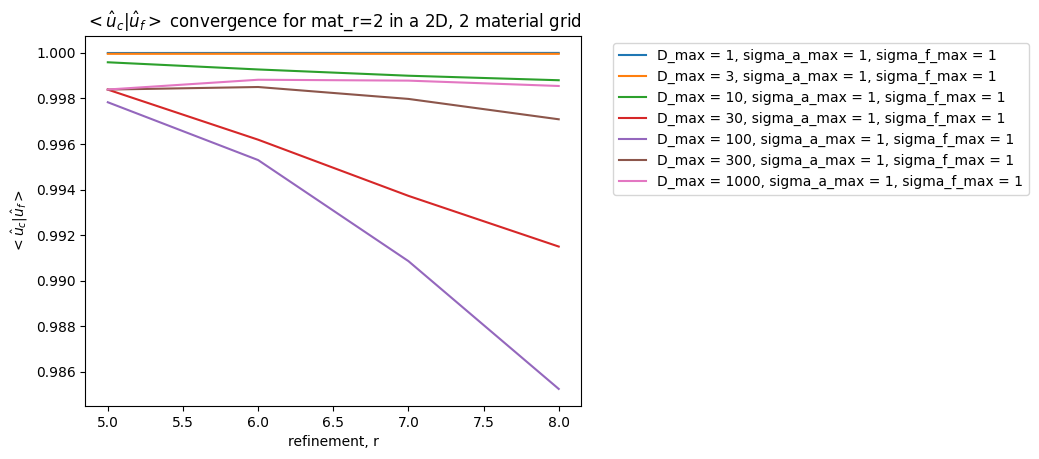

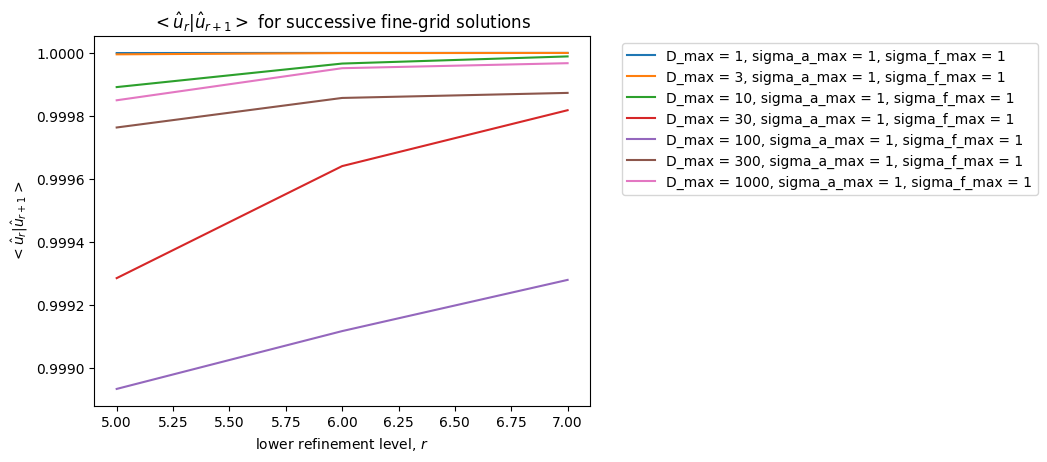

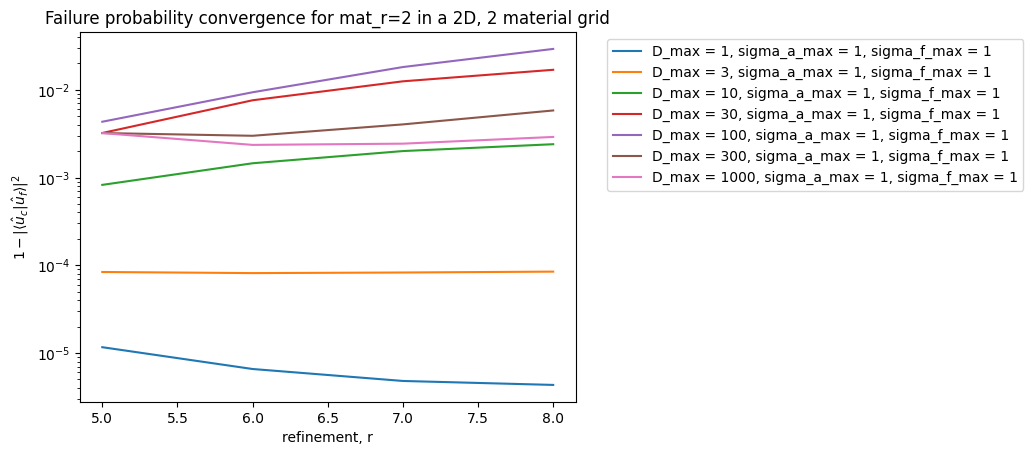

In [8]:
min_r = 5 # minimum refinement level for the fine solutions
max_r = 8 # maximum refinement level for the fine solutions
coarse_r = 4 # refinement level for the reference solution
mat_r = 2 # refinement level of the 2-material checkerboard material grid
D_max_list = [1,3,10,30,100,300,1000]
sigma_a_max_list = [1]
sigma_f_max_list = [1]

#material_coefficients = [(D_max, sigma_a_max, sigma_f_max) for D_max in D_max_list for sigma_a_max in sigma_a_max_list for sigma_f_max in sigma_f_max_list]
material_coefficients = list(itertools.product(D_max_list, sigma_a_max_list, sigma_f_max_list))
material_labels = [f"D_max = {D_max}, sigma_a_max = {sigma_a_max}, sigma_f_max = {sigma_f_max}" for D_max, sigma_a_max, sigma_f_max in material_coefficients]
fine_sol_overlap_list, successive_fine_overlap_list = get_fine_overlaps(material_coefficients, min_r, max_r, coarse_r, mat_r, geometry="checkerboard")

# plot the l2 norm of the error between the fine and coarse states
'''for i in range(len(D_max_list)):
    plt.semilogy(list(range(min_r, max_r+1)), eigenvector_l2_error_list[i])
    plt.xlabel("refinement, r")
    plt.ylabel(r'$|| \hat{u}_c - \hat{u}_f ||$')
plt.title(r'$|| \hat{u}_c - \hat{u}_f ||$ convergence for mat_r=' + str(mat_r) + ' in a 2D, 2 material grid')
plt.legend([f"D_max = {D_max}" for D_max in D_max_list])
plt.show()'''

# plot the inner product of the fine and coarse states
for i in range(len(D_max_list)*len(sigma_a_max_list)*len(sigma_f_max_list)):
    plt.plot(list(range(min_r, max_r+1)), fine_sol_overlap_list[i], label=material_labels[i])
    plt.xlabel("refinement, r")
    plt.ylabel(r'$< \hat{u}_c | \hat{u}_f>$')
plt.title(r'$< \hat{u}_c | \hat{u}_f>$ convergence for mat_r=' + str(mat_r) + ' in a 2D, 2 material grid')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.show()

# plot the inner products of successive fine-grid solutions
# The point at r compares the solutions at refinement levels r and r+1.
for i in range(len(D_max_list)*len(sigma_a_max_list)*len(sigma_f_max_list)):
    plt.plot(list(range(min_r, max_r)), successive_fine_overlap_list[i], label=material_labels[i])
plt.xlabel(r"lower refinement level, $r$")
plt.ylabel(r'$< \hat{u}_r | \hat{u}_{r+1}>$')
plt.title(r'$< \hat{u}_r | \hat{u}_{r+1}>$ for successive fine-grid solutions')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.show()

# Plot the failure probability, one minus the squared coarse-to-fine overlap.
for i in range(len(D_max_list)*len(sigma_a_max_list)*len(sigma_f_max_list)):
    plt.semilogy(list(range(min_r, max_r+1)), 1 - np.square(fine_sol_overlap_list[i]), label=material_labels[i])
    plt.xlabel("refinement, r")
    plt.ylabel(r'$1 - |\langle \hat{u}_c | \hat{u}_f \rangle|^2$')
plt.title(r'Failure probability convergence for mat_r=' + str(mat_r) + ' in a 2D, 2 material grid')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.show()




# Run 2D uniform superposition overlap simulations

In [9]:
min_r = 3 # minimum refinement level for the fine solutions
max_r = 8 # maximum refinement level for the fine solutions
mat_r_list = [2] # refinement level of the 2-material checkerboard material grid
D_min_list = [1]
D_max_list = [1,3,10,30,100]
sigma_a_min_list = [1]
sigma_a_max_list = [1]
sigma_f_min_list = [1]
sigma_f_max_list = [1]

#material_coefficients = [(D_max, sigma_a_max, sigma_f_max) for D_max in D_max_list for sigma_a_max in sigma_a_max_list for sigma_f_max in sigma_f_max_list]
material_coefficients = list(itertools.product(mat_r_list, D_min_list, D_max_list, sigma_a_min_list, sigma_a_max_list, sigma_f_min_list, sigma_f_max_list))
#material_labels = [f"D_max = {D_max}, sigma_a_max = {sigma_a_max}, sigma_f_max = {sigma_f_max}" for D_max, sigma_a_max, sigma_f_max in material_coefficients] # material labels with cross section values included
material_labels = [f"D_max = {D_max}" for mat_r, D_min, D_max, sigma_a_min, sigma_a_max, sigma_f_min, sigma_f_max in material_coefficients] # material labels without cross section values
fine_sol_overlap_list, successive_fine_overlap_list, fine_l1_norm_list, fine_l2_norm_list = get_uniform_superposition_overlaps(material_coefficients, min_r, max_r, geometry="checkerboard", apply_b_sqrt=True)
print("fine_sol_overlap_list = ", fine_sol_overlap_list)
print("successive_fine_overlap_list = ", successive_fine_overlap_list)
print("fine_l1_norm_list = ", fine_l1_norm_list)
print("fine_l2_norm_list = ", fine_l2_norm_list)


mat_r: 2, D_min: 1, D_max: 1, sigma_a_min: 1, sigma_a_max: 1, sigma_f_min: 1, sigma_f_max: 1, level: 3, lambda1: 20.994161312494537, full_size: 81
mat_r: 2, D_min: 1, D_max: 1, sigma_a_min: 1, sigma_a_max: 1, sigma_f_min: 1, sigma_f_max: 1, level: 4, lambda1: 20.80270735679788, full_size: 289
mat_r: 2, D_min: 1, D_max: 1, sigma_a_min: 1, sigma_a_max: 1, sigma_f_min: 1, sigma_f_max: 1, level: 5, lambda1: 20.755068235068748, full_size: 1089
mat_r: 2, D_min: 1, D_max: 1, sigma_a_min: 1, sigma_a_max: 1, sigma_f_min: 1, sigma_f_max: 1, level: 6, lambda1: 20.743172706514038, full_size: 4225
mat_r: 2, D_min: 1, D_max: 1, sigma_a_min: 1, sigma_a_max: 1, sigma_f_min: 1, sigma_f_max: 1, level: 7, lambda1: 20.740199718588208, full_size: 16641
mat_r: 2, D_min: 1, D_max: 1, sigma_a_min: 1, sigma_a_max: 1, sigma_f_min: 1, sigma_f_max: 1, level: 8, lambda1: 20.73945652754947, full_size: 66049
Refinement values:  [3, 4, 5, 6, 7, 8]
|| s_{uniform} - \hat{u}_f || : [0.44362266163846825, 0.53156519313681

# cached 2D results, base case:
- 2D 4x4 grid
- nu sigma_f = 1
- sigma_a = 1
- D_min = 1

In [ ]:
min_r = 3 # minimum refinement level for the fine solutions
max_r = 10 # maximum refinement level for the fine solutions
coarse_r = 3 # refinement level for the reference solution
mat_r_list = [2] # refinement level of the 2-material checkerboard material grid
D_min_list = [1]
D_max_list = [1,3,10,30,100]
sigma_a_min_list = [1]
sigma_a_max_list = [1]
sigma_f_min_list = [1]
sigma_f_max_list = [1]
material_coefficients = list(itertools.product(mat_r_list, D_min_list, D_max_list, sigma_a_min_list, sigma_a_max_list, sigma_f_min_list, sigma_f_max_list))
material_labels = [f"D_max = {D_max}" for mat_r, D_min, D_max, sigma_a_min, sigma_a_max, sigma_f_min, sigma_f_max in material_coefficients] # material labels without cross section values

fine_sol_overlap_list =  [[0.9015994670404004, 0.8587192227227111, 0.8352797221232442, 0.8230805756448418, 0.8168636550651759, 0.8137261744899885, 0.8121502191504021, 0.8113604427569722, 0.8109651055101152], [0.8903326513893536, 0.8443764530517202, 0.8198602925151, 0.8073020829147813, 0.8009722514570129, 0.7978036698154711, 0.7962219819174179, 0.7954331813071508, 0.7950398446691984], [0.8689158635407821, 0.8135506604079936, 0.7828928684569809, 0.7664739491128088, 0.7577526037270531, 0.7531235794883662, 0.7506602642761893, 0.7493438487236885, 0.7486367668237697], [0.8394120853194348, 0.7875313177922918, 0.7564200414635471, 0.7376133359282333, 0.7259722870104343, 0.7185688605839495, 0.7137299932672442, 0.7104875994682626, 0.7082689785915474], [0.6587823658765775, 0.6602415105642507, 0.6521488519485628, 0.6501638273167714, 0.651320401075041, 0.6535217899123429, 0.6557664737307107, 0.6576674513160751, 0.6591343626067878]]
successive_fine_overlap_list =  [[0.9998140546538673, 0.9999806523048652, 0.9999978843984382, 0.9999997563434487, 0.9999999709012607, 0.9999999964493985, 0.9999999995616539, 0.9999999999455507], [0.999410067043428, 0.9999264799323543, 0.9999905222443353, 0.9999987446895945, 0.9999998310314111, 0.9999999770097957, 0.9999999968409572, 0.999999999561196], [0.9973456743958011, 0.9994676150718296, 0.9998640042797138, 0.9999605100780696, 0.9999877814957204, 0.9999960724592171, 0.9999987072255421, 0.9999995684946188], [0.9926778932625686, 0.998590827628981, 0.9993325573789241, 0.9996465427035301, 0.9998182623262033, 0.9999073488679835, 0.9999525814134325, 0.9999755666125931], [0.983343304158908, 0.9980164443341796, 0.9991310797820188, 0.9991844156703801, 0.9992968401198801, 0.9994405354786893, 0.9995742104283469, 0.9996845417050856]]
fine_l1_norm_list =  [[0.100176002828469, 0.05051854911869577, 0.025312574707276297, 0.01266293386852306, 0.006332297250017669, 0.003166252398908445, 0.001583139170702639, 0.0007915712067435648, 0.00039578580604507016], [0.09887790364532495, 0.049666521989429786, 0.024844120731521556, 0.012420028971309371, 0.006209087711212411, 0.0031042945542412758, 0.0015520896520593561, 0.000776032374590572, 0.00038801358973333214], [0.096470944381403, 0.047842251884707906, 0.023721901088265922, 0.011791604410677886, 0.005874010409921089, 0.002930436616435296, 0.0014632746857027306, 0.0007310670827779496, 0.00036536688356123627], [0.09343553345721128, 0.04633620212940126, 0.02292187419477641, 0.011347766218429044, 0.005627662665147131, 0.0027959829089717727, 0.0013912858200900054, 0.0006931585344539628, 0.0003456656668719835], [0.07394835764545948, 0.03893571474939623, 0.01977355504407545, 0.010003785173950607, 0.005049130793728153, 0.002542900606528964, 0.0012782987063023302, 0.0006416269355360392, 0.0003216858931199555]]
fine_l2_norm_list =  [[0.1220891805383855, 0.06211631902636376, 0.03120088504403305, 0.01561879167196035, 0.007811719758515852, 0.0039061522108406826, 0.0019531127602824714, 0.000976560969034344, 0.00048828105856684687], [0.12193842003636, 0.062084815062673555, 0.031196014048883607, 0.015618117813590227, 0.007811631146257172, 0.0039061408460512076, 0.0019531113210613414, 0.0009765607879453864, 0.00048828103585592177], [0.12143329435962492, 0.06195787604703165, 0.03117465866791119, 0.015614941989903335, 0.007811187035784696, 0.003906081065663811, 0.0019531034748448283, 0.000976559775363748, 0.00048828090663711793], [0.11858026844997785, 0.06142923959959047, 0.031106313754728436, 0.015606613135846756, 0.007810159772668125, 0.003905951640059404, 0.0019530869299575874, 0.0009765576464437877, 0.0004882806324038895], [0.10401230519453206, 0.059084442785282736, 0.03078909783256632, 0.01556768540945446, 0.0078055815808742, 0.0039054218443345446, 0.0019530257735071214, 0.0009765505519243966, 0.0004882798021290554]]


# cached 2D results, 0 fission_min, 128x128 grid case:
- 2D 128 x 128 grid
- nu sigma_f min = 0
- nu sigma_f max = 1
- sigma_a = 1
- D_min = 1

this was done to try to see if we get similar poor convergence to C5G7 when we use a larger checkerboard grid and zero fission cross section regions

In [83]:
min_r = 3 # minimum refinement level for the fine solutions
max_r = 10 # maximum refinement level for the fine solutions
coarse_r = 3 # refinement level for the reference solution
mat_r_list = [7] # refinement level of the 2-material checkerboard material grid
D_min_list = [1]
D_max_list = [1,3,10,30,100]
sigma_a_min_list = [1]
sigma_a_max_list = [1]
sigma_f_min_list = [0]
sigma_f_max_list = [1]
material_coefficients = list(itertools.product(mat_r_list, D_min_list, D_max_list, sigma_a_min_list, sigma_a_max_list, sigma_f_min_list, sigma_f_max_list))
material_labels = [f"D_max = {D_max}" for mat_r, D_min, D_max, sigma_a_min, sigma_a_max, sigma_f_min, sigma_f_max in material_coefficients] # material labels without cross section values

fine_sol_overlap_list = [[0.9015994670404004, 0.858719222722711, 0.8352797221232441, 0.8230805756448418, 0.8168636545687581, 0.7476224060988542, 0.6743532529735492, 0.6271292176517977], [0.9015994670404003, 0.8587192227227111, 0.8352797221232443, 0.8230805756448424, 0.8168629514516568, 0.7470925058422134, 0.6737649566071995, 0.6265421356798463], [0.9015994670404004, 0.8587192227227112, 0.8352797221232441, 0.8230805756448423, 0.816861780341914, 0.7462027342069392, 0.672662886171358, 0.6253769580597637], [0.9015994670404004, 0.8587192227227112, 0.8352797221232442, 0.8230805756448424, 0.8168612071669308, 0.745761042112821, 0.6720411355024202, 0.6246704097396348], [0.9015994670404004, 0.8587192227227111, 0.8352797221232441, 0.8230805756448418, 0.8168609686853747, 0.745575691087515, 0.6717587839276945, 0.624332806627648]]
successive_fine_overlap_list = [[0.9998140546538673, 0.9999806523048652, 0.999997884398438, 0.9999997551233227, 0.9187714806689062, 0.9402774840844513, 0.9664945693080979], [0.9998140546538674, 0.9999806523048653, 0.9999978843984382, 0.9999997512574736, 0.9187670203094737, 0.9402789116765323, 0.9664941283044324], [0.9998140546538674, 0.9999806523048652, 0.9999978843984384, 0.9999997473503393, 0.9187585638912044, 0.9402786232537114, 0.966493825298515], [0.9998140546538673, 0.9999806523048654, 0.9999978843984382, 0.9999997456242216, 0.9187534909576385, 0.9402777130098094, 0.9664934344515487], [0.9998140546538675, 0.9999806523048654, 0.9999978843984382, 0.9999997449255443, 0.9187511800584957, 0.9402771161980488, 0.9664931596345968]]
fine_l1_norm_list = [[0.100176002828469, 0.05051854911869581, 0.02531257470727634, 0.012662933868523072, 0.006332297247836262, 0.002909033390952463, 0.0013145286800062828, 0.0006118333917729197], [0.10017600282846896, 0.05051854911869576, 0.02531257470727634, 0.012662933868523067, 0.006332291772937903, 0.0029069678094773175, 0.0013133812589264183, 0.0006112605445625127], [0.10017600282846914, 0.05051854911869577, 0.02531257470727631, 0.012662933868523081, 0.006332282663108545, 0.002903499397726144, 0.0013112319529154915, 0.0006101236454610898], [0.10017600282846902, 0.05051854911869576, 0.02531257470727629, 0.012662933868523065, 0.006332278205186269, 0.0029017776703025738, 0.001310019433098471, 0.0006094342520578532], [0.10017600282846909, 0.050518549118695744, 0.02531257470727631, 0.01266293386852307, 0.006332276350449168, 0.002901055175618509, 0.001309468811925982, 0.0006091048483480833]]
fine_l2_norm_list = [[0.1220891805383855, 0.06211631902636382, 0.031200885044033098, 0.015618791671960364, 0.0078117197499269425, 0.0037308812301465473, 0.0018838805282356413, 0.0009560706305851613], [0.12208918053838548, 0.06211631902636375, 0.031200885044033094, 0.015618791671960345, 0.007811719723875185, 0.003730885806255705, 0.001883882653394778, 0.0009560707670751385], [0.12208918053838567, 0.06211631902636376, 0.03120088504403307, 0.015618791671960366, 0.007811719697961711, 0.0037308829371951063, 0.00188388285658014, 0.0009560707876211138], [0.12208918053838554, 0.06211631902636375, 0.031200885044033046, 0.015618791671960343, 0.007811719686575897, 0.003730880810093499, 0.0018838825521456234, 0.0009560707255942761], [0.12208918053838563, 0.062116319026363734, 0.03120088504403308, 0.015618791671960362, 0.0078117196819758004, 0.0037308798478299754, 0.00188388235933253, 0.0009560706820809666]]

# cached 2D results, 0 fission_min, varying material grid dimensions:
- 2D grid
- nu sigma_f min = 0
- nu sigma_f max = 1
- sigma_a = 1
- D_min = 1

In [128]:
min_r = 3 # minimum refinement level for the fine solutions
max_r = 11 # maximum refinement level for the fine solutions
coarse_r = 3 # refinement level for the reference solution
mat_r_list = [2,3,4,5,6,7] # refinement level of the 2-material checkerboard material grid
D_min_list = [1]
D_max_list = [10]
sigma_a_min_list = [1]
sigma_a_max_list = [1]
sigma_f_min_list = [0]
sigma_f_max_list = [1]
material_coefficients = list(itertools.product(mat_r_list, D_min_list, D_max_list, sigma_a_min_list, sigma_a_max_list, sigma_f_min_list, sigma_f_max_list))
#material_labels = [f"r_m = {mat_r}" for mat_r, D_min, D_max, sigma_a_min, sigma_a_max, sigma_f_min, sigma_f_max in material_coefficients] # material labels without cross section values
material_labels = [f"{int(2**mat_r)} X {int(2**mat_r)} checkerboard ($r_m$ = {mat_r})" for mat_r, D_min, D_max, sigma_a_min, sigma_a_max, sigma_f_min, sigma_f_max in material_coefficients] # material labels


fine_sol_overlap_list =  [[0.7633253127334367, 0.6332398443603425, 0.5631211864362139, 0.5269051025407436, 0.5083355459450629, 0.4988084754965886, 0.49390571282140494, 0.4913726148671254, 0.4900580264102412], [0.8989389617609053, 0.7644098607248317, 0.6635222241933669, 0.6050714730277833, 0.5739565134801076, 0.5578758778410828, 0.5496626902864847, 0.5454864530649601, 0.5433650802611786], [0.9015994670404006, 0.8581560175889924, 0.7557584854831061, 0.6693115915352316, 0.6167523644805923, 0.5882418203552583, 0.5734102008101659, 0.5658322902014854, 0.5619913834853422], [0.9015994670404005, 0.858719222722711, 0.8351855481513917, 0.7504774721635712, 0.6713779301940098, 0.6218201041898043, 0.5946409704567399, 0.580444934989924, 0.5731869844690793], [0.9015994670404005, 0.8587192227227111, 0.8352797221232441, 0.823066808753557, 0.7476538288438699, 0.6722569982139995, 0.6242121156863102, 0.5977054233481182, 0.5838298632915457], [0.9015994670404006, 0.8587192227227111, 0.8352797221232441, 0.8230805756448422, 0.816861780341914, 0.7462027342069338, 0.67266288617135, 0.6253769572403353, 0.5992079406866135]]
successive_fine_overlap_list =  [[0.9397610319938179, 0.9673477262948027, 0.9831729475313743, 0.9914662908658025, 0.9957046658819958, 0.9978458118009688, 0.9989214769070427, 0.9994604473740103], [0.9156598738442423, 0.9402995754118892, 0.9667324774821292, 0.9826831324899815, 0.9911788859219289, 0.9955495723303203, 0.9977649801827242, 0.9988800789700029], [0.9997729047107269, 0.9179657004336065, 0.940298470381412, 0.9665566429414972, 0.9825600569128844, 0.9911092664041172, 0.9955126552586339, 0.9977459299991538], [0.9998140546538674, 0.9999781979624462, 0.9185659839003483, 0.9402851194236564, 0.9665092648975427, 0.9825283629865547, 0.9910915736550654, 0.9955033304663814], [0.9998140546538675, 0.9999806523048652, 0.9999977370086317, 0.9187198050017126, 0.9402800990347514, 0.9664969608788224, 0.9825203009706559, 0.9910871015864141], [0.9998140546538675, 0.9999806523048652, 0.9999978843984383, 0.9999997473503393, 0.9187585638912041, 0.9402786232537111, 0.9664938250327648, 0.9825182674034253]]
fine_l1_norm_list =  [[0.08444576323268163, 0.03720603600252384, 0.017059102293329888, 0.008105602144388983, 0.0039405078322721, 0.0019408793297118726, 0.0009627779584538177, 0.0004793877657808203, 0.00023916934488333848], [0.09985465224104255, 0.04491599127422469, 0.02010056656893369, 0.009308041411454422, 0.004449183244331084, 0.002170711859564029, 0.001071465811832452, 0.0005321817278843144, 0.00026518547328156035], [0.10017600282846906, 0.050484181914323814, 0.022895332722671528, 0.010296270148032867, 0.004780923866295106, 0.002288866084602926, 0.0011177571131232565, 0.0005520313076852169, 0.00027427590704940513], [0.10017600282846913, 0.05051854911869577, 0.025309673229532013, 0.011544981298175227, 0.0052043719311943085, 0.0024195201183884263, 0.0011591425423481691, 0.0005662875365410641, 0.00027973983995819527], [0.10017600282846903, 0.05051854911869569, 0.025312574707276297, 0.012662720420082395, 0.0057956614005731915, 0.0026157721845150492, 0.0012167860412088045, 0.0005831270311345904, 0.0002849340212406367], [0.10017600282846914, 0.050518549118695785, 0.025312574707276343, 0.012662933868523062, 0.006332282663108532, 0.002903499397726123, 0.0013112319529154778, 0.0006101236446616486, 0.00029243918299277216]]
fine_l2_norm_list =  [[0.1167139908180325, 0.060024442531930164, 0.03058144323972755, 0.01545185910379338, 0.007768468895346496, 0.0038951481877137874, 0.001950337659041447, 0.0009758641644337156, 0.0004881064772806742], [0.1220365572539075, 0.05935479750450971, 0.030110304648213956, 0.015295556075865649, 0.007724696542740797, 0.0038836280877174523, 0.0019473861219257017, 0.0009751173753277058, 0.000487918668483696], [0.12208918053838556, 0.06211445544044201, 0.02980476786688963, 0.015067212621914156, 0.007648389800993693, 0.003862210221768416, 0.0019417442890214387, 0.0009736713370723287, 0.0004875527326334457], [0.12208918053838565, 0.062116319026363755, 0.031200824290095054, 0.014918479631144479, 0.0075350788951019515, 0.003824263451961853, 0.0019310866114768928, 0.0009708632440080214, 0.0004868329267029395], [0.12208918053838552, 0.062116319026363664, 0.031200885044033053, 0.015618789745065014, 0.0074612600332097335, 0.0037677207673687666, 0.0019121396730503453, 0.0009655408866991753, 0.00048543049153866553], [0.12208918053838567, 0.06211631902636378, 0.031200885044033108, 0.015618791671960345, 0.007811719697961694, 0.003730882937195107, 0.0018838828565801427, 0.0009560707875308989, 0.0004827701336909474]]


# plot 2D results

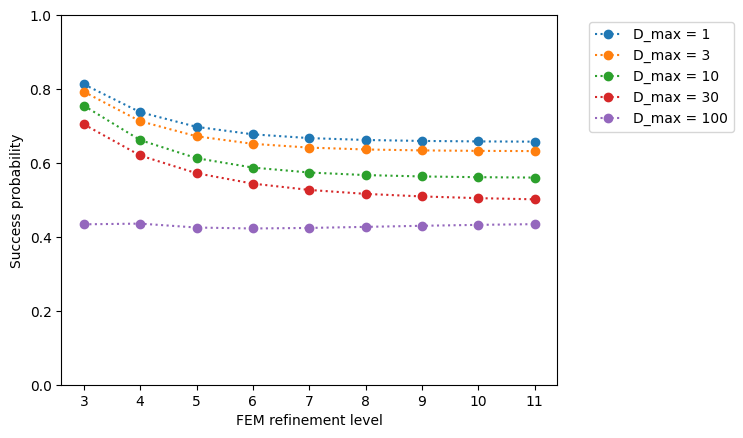

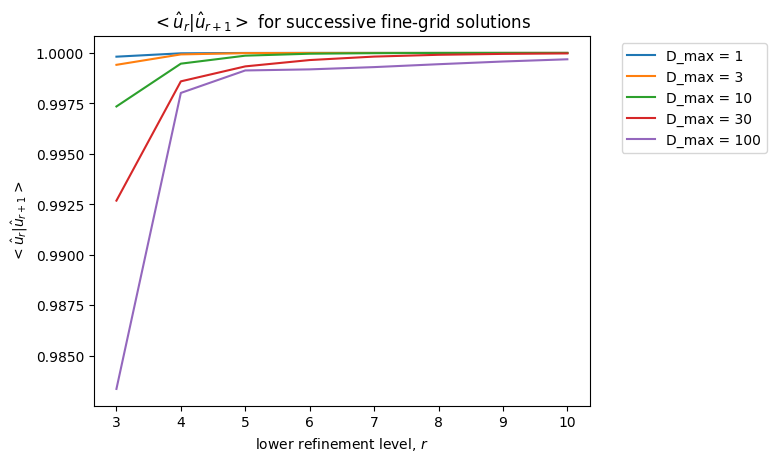

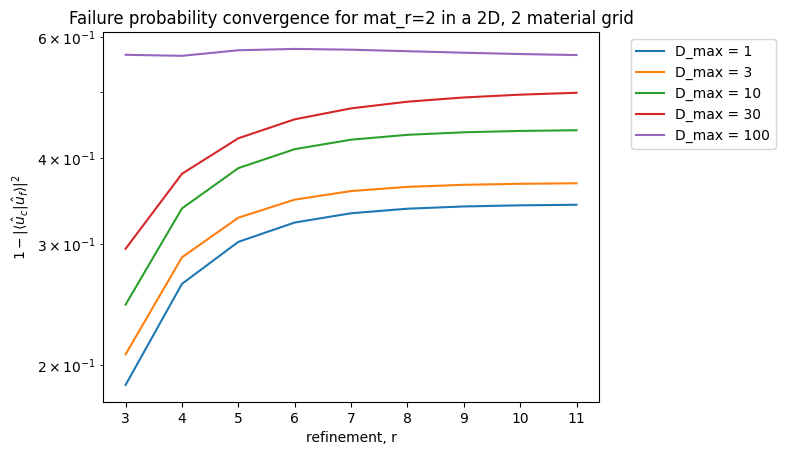

In [134]:
# plot the l2 norm of the error between the fine and coarse states
'''for i in range(len(D_max_list)):
    plt.semilogy(list(range(min_r, max_r+1)), eigenvector_l2_error_list[i])
    plt.xlabel("refinement, r")
    plt.ylabel(r'$|| \hat{u}_c - \hat{u}_f ||$')
plt.title(r'$|| \hat{u}_c - \hat{u}_f ||$ convergence for mat_r=' + str(mat_r) + ' in a 2D, 2 material grid')
plt.legend([f"D_max = {D_max}" for D_max in D_max_list])
plt.show()'''

# Plot the success probability and the finest-grid continuous L1/L2 ratio.
lines = []  # store the line objects for each material
for i in range(len(material_coefficients)):
    success_probability = np.square(fine_sol_overlap_list[i])
    line, = plt.plot(
        list(range(max(min_r, material_coefficients[i][0]), max_r+1)),
        success_probability[max(min_r, material_coefficients[i][0])-min_r:], ':o', 
        label=material_labels[i]
    )
    plt.xticks(range(min_r, max_r+1))
    lines.append(line)
# Plot the success probability and the finest-grid continuous L1/L2 ratio.
'''for i in range(len(material_coefficients)):
    expected_overlap_ratio = fine_l1_norm_list[i][-1] / fine_l2_norm_list[i][-1]
    expected_success_probability = np.square(expected_overlap_ratio)
    plt.axhline(
        expected_success_probability,
        color=lines[i].get_color(),
        linestyle="--",
        #label=material_labels[i] + r' $||u_h||_{L^1}/||u_h||_{L^2}$',
    )'''

plt.xlabel("FEM refinement level")
plt.ylabel('Success probability')
#plt.ylabel(r'$|\langle s_{uniform} | \hat{u}_f \rangle|^2$')
plt.ylim([0,1])
#plt.title(r'Success probability convergence for mat_r=' + str(mat_r) + ' in a 2D, 2 material grid')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.show()

# plot the inner products of successive fine-grid solutions
# The point at r compares the solutions at refinement levels r and r+1.
for i in range(len(material_coefficients)):
    plt.plot(list(range(min_r, max_r)), successive_fine_overlap_list[i], label=material_labels[i])
plt.xlabel(r"lower refinement level, $r$")
plt.ylabel(r'$< \hat{u}_r | \hat{u}_{r+1}>$')
plt.title(r'$< \hat{u}_r | \hat{u}_{r+1}>$ for successive fine-grid solutions')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.show()

# Plot the failure probability, one minus the squared coarse-to-fine overlap.
for i in range(len(material_coefficients)):
    plt.semilogy(list(range(min_r, max_r+1)), 1 - np.square(fine_sol_overlap_list[i]), label=material_labels[i])
    plt.xlabel("refinement, r")
    plt.ylabel(r'$1 - |\langle \hat{u}_c | \hat{u}_f \rangle|^2$')
plt.title(r'Failure probability convergence for mat_r=' + str(mat_r) + ' in a 2D, 2 material grid')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.show()



# Run 3D uniform superposition eigenvector overlap simulations

In [7]:
min_r = 3 # minimum refinement level for the fine solutions
max_r = 6 # maximum refinement level for the fine solutions
mat_r_list = [2] # refinement level of the 2-material checkerboard material grid
D_min_list = [1]
D_max_list = [10,30,100]
sigma_a_min_list = [1]
sigma_a_max_list = [1]
sigma_f_min_list = [1]
sigma_f_max_list = [1]

#material_coefficients = [(D_max, sigma_a_max, sigma_f_max) for D_max in D_max_list for sigma_a_max in sigma_a_max_list for sigma_f_max in sigma_f_max_list]
material_coefficients = list(itertools.product(mat_r_list, D_min_list, D_max_list, sigma_a_min_list, sigma_a_max_list, sigma_f_min_list, sigma_f_max_list))
#material_labels = [f"D_max = {D_max}, sigma_a_max = {sigma_a_max}, sigma_f_max = {sigma_f_max}" for D_max, sigma_a_max, sigma_f_max in material_coefficients] # material labels with cross section values included
material_labels = [f"D_max = {D_max}" for mat_r, D_min, D_max, sigma_a_min, sigma_a_max, sigma_f_min, sigma_f_max in material_coefficients] # material labels without cross section values
fine_sol_overlap_list, successive_fine_overlap_list, fine_l1_norm_list, fine_l2_norm_list = get_uniform_superposition_overlaps(material_coefficients, min_r, max_r, geometry="checkerboard", dim=3, apply_b_sqrt=False)
print("fine_sol_overlap_list:", fine_sol_overlap_list)
print("successive_fine_overlap_list:", successive_fine_overlap_list)
print("fine_l1_norm_list:", fine_l1_norm_list)
print("fine_l2_norm_list:", fine_l2_norm_list)



mat_r: 2, D_min: 1, D_max: 10, sigma_a_min: 1, sigma_a_max: 1, sigma_f_min: 1, sigma_f_max: 1, level: 3, lambda1: 148.43192945676898, full_size: 729
mat_r: 2, D_min: 1, D_max: 10, sigma_a_min: 1, sigma_a_max: 1, sigma_f_min: 1, sigma_f_max: 1, level: 4, lambda1: 137.48318178875473, full_size: 4913
mat_r: 2, D_min: 1, D_max: 10, sigma_a_min: 1, sigma_a_max: 1, sigma_f_min: 1, sigma_f_max: 1, level: 5, lambda1: 132.1453024759206, full_size: 35937
mat_r: 2, D_min: 1, D_max: 10, sigma_a_min: 1, sigma_a_max: 1, sigma_f_min: 1, sigma_f_max: 1, level: 6, lambda1: 129.26606408633657, full_size: 274625
Refinement values:  [3, 4, 5, 6]
|| s_{uniform} - \hat{u}_f || : [0.5932776156372336, 0.6921117722130045, 0.7454875565135015, 0.7734993503013174]
< s_{uniform} | \hat{u}_f> : [0.8240108353918995, 0.760490647382087, 0.7221241515417646, 0.7008493775417198]
< \hat{u}_r | \hat{u}_{r+1}> : [0.9963510331718175, 0.9994080728785881, 0.9998420299688797]
||u_h||_{L^1(\Omega)} : [0.7134387301763909, 0.70023

# cache 3D simulation data, up to r=5

In [50]:
min_r = 3 # minimum refinement level for the fine solutions
max_r = 5 # maximum refinement level for the fine solutions
coarse_r = 3 # refinement level for the reference solution
mat_r = 2 # refinement level of the 2-material checkerboard material grid
D_max_list = [1,3,10,30,100]
sigma_a_max_list = [1]
sigma_f_max_list = [1]

fine_sol_overlap_list = [[0.8575858256375131, 0.7962201319857506, 0.7635205611180818], [0.8489334242147589, 0.7854375958126163, 0.75157729048008], [0.8240108353918995, 0.7604906473820873, 0.7221241515417648], [0.6723717642494473, 0.6968319381473627, 0.676906516476451], [0.34520966510868, 0.49207717886827756, 0.5149896020933264]]
successive_fine_overlap_list = [[0.9998588654055873, 0.9999912629713147], [0.9993715003465008, 0.9999312558667005], [0.9963510331718177, 0.9994080728785883], [0.9823365667786497, 0.9980209186433601], [0.9600223747840056, 0.997566959218679]]
fine_l1_norm_list = [[0.7295118370434703, 0.7297530378238448, 0.7297679288238429], [0.7237055204668985, 0.7203184644705318, 0.7184756804784962], [0.713438730176391, 0.7002382178695394, 0.6910580280088994], [0.6763817431691903, 0.6611650288348272, 0.6519305249477048], [0.4785180710536731, 0.5052815877533365, 0.5058071734850589]]
fine_l2_norm_list = [[0.9999999999999999, 0.9999999999999999, 0.9999999999999998], [1.0000000000000002, 1.0, 0.9999999999999999], [0.9999999999999998, 1.0000000000000002, 1.0], [1.0, 1.0, 1.0], [0.9999999999999999, 1.0000000000000002, 1.0]]

# cache 3D simulation data, up to r=6:

In [10]:
min_r = 3 # minimum refinement level for the fine solutions
max_r = 6 # maximum refinement level for the fine solutions
coarse_r = 3 # refinement level for the reference solution
mat_r = 2 # refinement level of the 2-material checkerboard material grid
D_max_list = [1,3,10,30,100]
sigma_a_max_list = [1]
sigma_f_max_list = [1]

#material_coefficients = [(D_max, sigma_a_max, sigma_f_max) for D_max in D_max_list for sigma_a_max in sigma_a_max_list for sigma_f_max in sigma_f_max_list]
material_coefficients = list(itertools.product(mat_r_list, D_min_list, D_max_list, sigma_a_min_list, sigma_a_max_list, sigma_f_min_list, sigma_f_max_list))
#material_labels = [f"D_max = {D_max}, sigma_a_max = {sigma_a_max}, sigma_f_max = {sigma_f_max}" for D_max, sigma_a_max, sigma_f_max in material_coefficients] # material labels with cross section values included
material_labels = [f"D_max = {D_max}" for mat_r, D_min, D_max, sigma_a_min, sigma_a_max, sigma_f_min, sigma_f_max in material_coefficients] # material labels without cross section values

fine_sol_overlap_list = [[0.8557607771399741, 0.7948445213500568, 0.7622982655940925, 0.7455923801262138], [0.8435788569216747, 0.7785990130950163, 0.7444327751985658, 0.7271283928853598],[0.8240108353918995, 0.760490647382087, 0.7221241515417646, 0.7008493775417198], [0.6723717642494472, 0.6968319381473627, 0.6769065164764511, 0.6582952729228638], [0.3452096651086799, 0.4920771788682775, 0.5149896020933267, 0.5142844956772693]]
successive_fine_overlap_list = [[0.9995839471126781, 0.9999690709568979, 0.9999979582665697], [0.9992847111618095, 0.9999140072716955, 0.9999895438565135],[0.9963510331718175, 0.9994080728785881, 0.9998420299688797], [0.9823365667786499, 0.9980209186433598, 0.9992366298983097], [0.9600223747840054, 0.9975669592186788, 0.9994907422183563]]
fine_l1_norm_list = [[1.0084161201914843, 0.9970633799748403, 0.9935684005732662, 0.992640156437079], [0.9989191609204107, 0.9822621900787656, 0.9757914187845205, 0.9734455490716438],[0.7134387301763909, 0.7002382178695393, 0.6910580280088994, 0.6851300053268646], [0.6763817431691902, 0.6611650288348274, 0.6519305249477048, 0.6444537832026656], [0.47851807105367306, 0.5052815877533366, 0.5058071734850591, 0.5059047614247347]]
fine_l2_norm_list = [[1.3834975040742887, 1.3681718549478554, 1.3635416740278743, 1.3623156438884598], [1.3886568031680642, 1.3753579816173422, 1.3710900545847002, 1.3698438135398903],[0.9999999999999999, 0.9999999999999999, 0.9999999999999999, 1.0000000000000002], [0.9999999999999999, 1.0000000000000002, 1.0000000000000002, 1.0], [0.9999999999999998, 1.0000000000000002, 1.0, 1.0000000000000002]]

# plot results

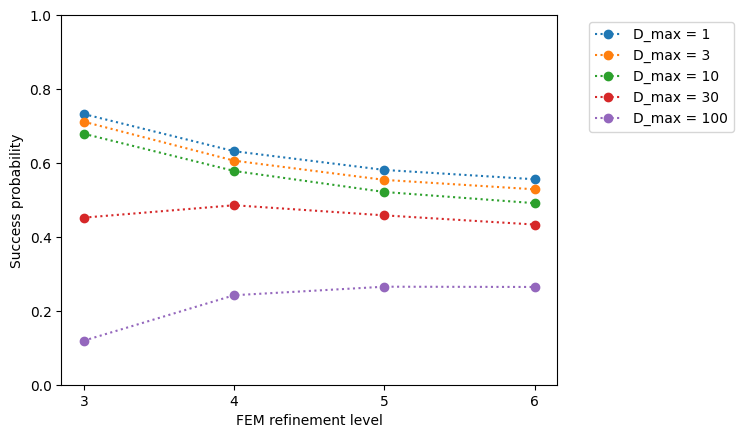

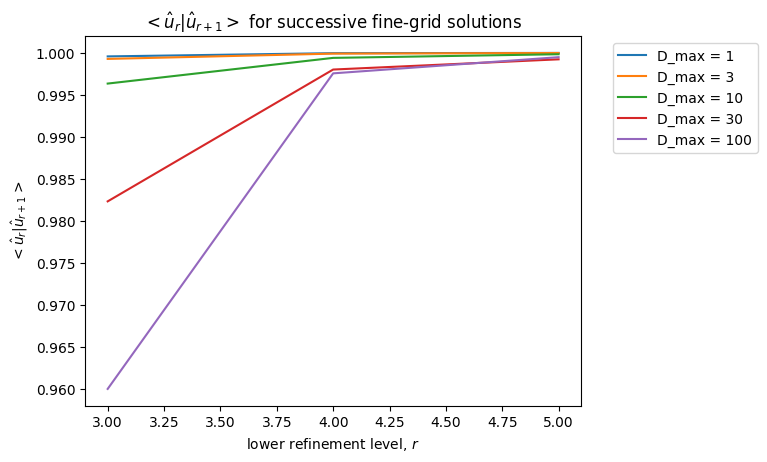

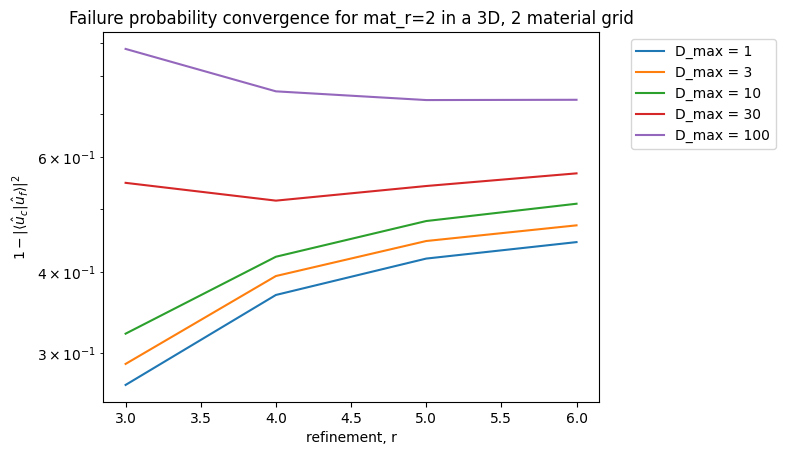

In [11]:
# plot the l2 norm of the error between the fine and coarse states
'''for i in range(len(D_max_list)):
    plt.semilogy(list(range(min_r, max_r+1)), eigenvector_l2_error_list[i])
    plt.xlabel("refinement, r")
    plt.ylabel(r'$|| \hat{u}_c - \hat{u}_f ||$')
plt.title(r'$|| \hat{u}_c - \hat{u}_f ||$ convergence for mat_r=' + str(mat_r) + ' in a 2D, 2 material grid')
plt.legend([f"D_max = {D_max}" for D_max in D_max_list])
plt.show()'''

# Plot the success probability and the finest-grid continuous L1/L2 ratio.
lines = []  # store the line objects for each material
for i in range(len(D_max_list)*len(sigma_a_max_list)*len(sigma_f_max_list)):
    success_probability = np.square(fine_sol_overlap_list[i])
    line, = plt.plot(
        list(range(min_r, max_r+1)),
        success_probability, ':o',
        label=material_labels[i],
    )
    plt.xticks(range(min_r, max_r+1))
    lines.append(line)
# Plot the success probability and the finest-grid continuous L1/L2 ratio.
'''for i in range(len(D_max_list)*len(sigma_a_max_list)*len(sigma_f_max_list)):
    expected_overlap_ratio = fine_l1_norm_list[i][-1] / fine_l2_norm_list[i][-1]
    expected_success_probability = np.square(expected_overlap_ratio)
    plt.axhline(
        expected_success_probability,
        color=lines[i].get_color(),
        linestyle="--",
        #label=material_labels[i] + r' $||u_h||_{L^1}/||u_h||_{L^2}$',
    )'''

plt.xlabel("FEM refinement level")
plt.ylabel('Success probability')
#plt.ylabel(r'$|\langle s_{uniform} | \hat{u}_f \rangle|^2$')
plt.ylim([0,1])
#plt.title(r'Success probability convergence for mat_r=' + str(mat_r) + ' in a 3D, 2 material grid')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.show()

# plot the inner products of successive fine-grid solutions
# The point at r compares the solutions at refinement levels r and r+1.
for i in range(len(D_max_list)*len(sigma_a_max_list)*len(sigma_f_max_list)):
    plt.plot(list(range(min_r, max_r)), successive_fine_overlap_list[i], label=material_labels[i])
plt.xlabel(r"lower refinement level, $r$")
plt.ylabel(r'$< \hat{u}_r | \hat{u}_{r+1}>$')
plt.title(r'$< \hat{u}_r | \hat{u}_{r+1}>$ for successive fine-grid solutions')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.show()

# Plot the failure probability, one minus the squared coarse-to-fine overlap.
for i in range(len(D_max_list)*len(sigma_a_max_list)*len(sigma_f_max_list)):
    plt.semilogy(list(range(min_r, max_r+1)), 1 - np.square(fine_sol_overlap_list[i]), label=material_labels[i])
    plt.xlabel("refinement, r")
    plt.ylabel(r'$1 - |\langle \hat{u}_c | \hat{u}_f \rangle|^2$')
plt.title(r'Failure probability convergence for mat_r=' + str(mat_r) + ' in a 3D, 2 material grid')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.show()

